## Defining Problem Statement and Analyzing basic metrics

### Business Problem

The Management team at Walmart Inc. wants to analyze the customer purchase behavior (specifically, purchase amount) against the customer’s gender and the various other factors to help the business make better decisions. They want to understand if the spending habits differ between male and female customers

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
df = pd.read_csv("https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/293/original/walmart_data.csv?1641285094")

In [3]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [4]:
df.shape

(550068, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


In [6]:
# to find whether there are duplicate rows in the dataset

df[df.duplicated()].shape

(0, 10)

* There are no duplicates rows.

### Convert categorical columns to 'category' type to save memory

In [7]:
# drop columns (if required) 'Product_ID', 'Occupation', 'City_Category',  'Stay_In_Current_City_Years' and 'Product_Category ' not in use to save memory

# df.drop(['Product_ID', 'Occupation', 'City_Category', 'Stay_In_Current_City_Years', 'Product_Category'], axis=1, inplace=True)

In [8]:
# Convert categorical columns to 'category' type
#cat_cols = ['Gender', 'Age', 'Marital_Status','Product_ID', 'Occupation', 'City_Category', 'Stay_In_Current_City_Years', 'Product_Category']
#for col in cat_cols:
    #df[col] = df[col].astype('category')

In [9]:
#df.info()

## Missing Value & Outlier Detection

In [10]:
## Check for null values
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category,0
Purchase,0


* There are no Null values.

## Business Insights based on Non- Graphical and Visual Analysis

### Purchase Behavior by Gender

In [11]:
# to find the count of Gender split

df["Gender"].value_counts()

,count
Gender,
M,414259
F,135809


In [12]:
# as seen in the head, there are multiple purchases made by the same User_IDs,
# hence we find the gender proportion and unique counts

df["Gender"].value_counts(normalize=True)

,proportion
Gender,
M,0.753105
F,0.246895


* Females and Males are around 1/4 and 3/4 of the total customers
* Gender Distribution: ~75% Male, ~25% Female (3:1 skew)

In [13]:
df.groupby('Gender')['User_ID'].nunique()

,User_ID
Gender,
F,1666
M,4225


* There are 5891 unique customers and the gender split is as mentioned above.

In [14]:
df.groupby("Gender")["Purchase"].describe().T

Gender,F,M
count,135809.000000,414259.00000
mean,8734.565765,9437.52604
std,4767.233289,5092.18621
min,12.000000,12.00000
25%,5433.000000,5863.00000
50%,7914.000000,8098.00000
75%,11400.000000,12454.00000
max,23959.000000,23961.00000


* Purchase Amount: Ranges from 12 to 23,961 across all users.
* There is a difference between Mean and Median purchases made by the 2 Genders, here the mean is greater than the median, hence there must be outliers on the higher side.
* Both genders have mean (average) purchase amounts, around 8,500 to 9,500.
* Similarly, both genders have similar median purchase amounts, around 8000.

<Axes: xlabel='Gender', ylabel='Purchase'>

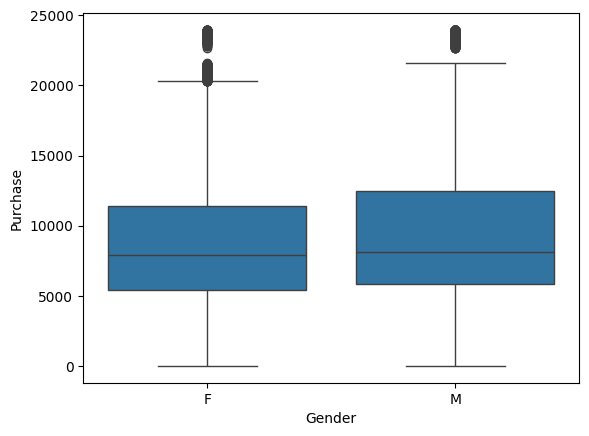

In [15]:
# Boxplot for outlier detection
sns.boxplot(x='Gender', y='Purchase', data=df)

* The interquartile ranges (middle 50% of data) are also similar, indicating comparable variability within each gender group.
* The overall range of purchase amounts appears similar for both, with whiskers extending from near 0 to around 12,000-13,000.
* Outliers are present in both groups, with several data points significantly higher than the main distribution, indicating some large purchase transactions.
* Purchase Distribution is Right-skewed. Most customers spend between 5,000–12,000.

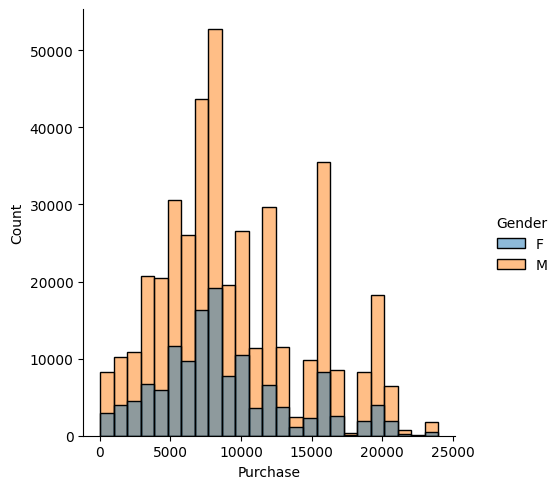

In [16]:
sns.displot(x='Purchase', data=df, bins=25, hue = "Gender")

### Business Insights based on Non- Graphical and Visual Analysis



* Males tend to have higher purchase amounts compared to females, as indicated by the taller orange bars in higher purchase ranges.
* Females have a more concentrated distribution at lower purchase amounts, with fewer transactions at higher amounts.
* Overall, the total number of transactions appears higher for males, especially in the mid to high purchase ranges.
* But this could be due to the higher number of the Males than the Females (approx 3 times)
* ### Hence for confirmation we move on to Confidence Interval using CLT

 ## Confidence Interval using CLT Central Limit Theorem:

* The means of the sample means is aprrox eqaual to that of the population mean, given that the pop mean and std are finite and the sample size is greater than 30

In [17]:
df.groupby("Gender")['Purchase'].describe().T

Gender,F,M
count,135809.000000,414259.00000
mean,8734.565765,9437.52604
std,4767.233289,5092.18621
min,12.000000,12.00000
25%,5433.000000,5863.00000
50%,7914.000000,8098.00000
75%,11400.000000,12454.00000
max,23959.000000,23961.00000


### CLT-1

In [18]:
# sample_size = 100
# iterations = 1000

In [19]:
male_sample_means_1 = [df[df["Gender"] == "M"]["Purchase"].sample(100).mean() for i in range(1000)]
female_sample_means_1= [df[df['Gender']=='F']['Purchase'].sample(100).mean() for i in range(1000)]

In [20]:
print('male_sample_means:',(np.mean(male_sample_means_1)))
print('female_sample_means:',(np.mean(female_sample_means_1)))

male_sample_means: 9449.73983
female_sample_means: 8737.07988


9449.73983


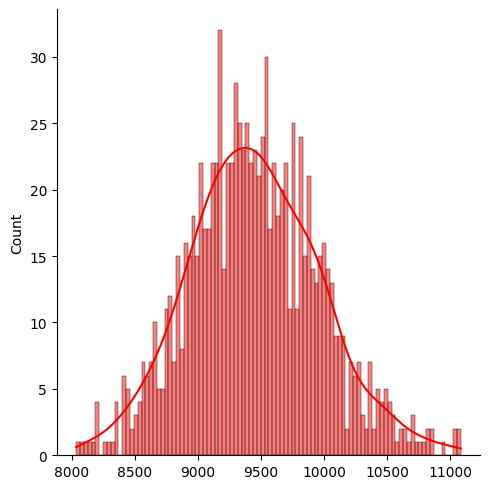

In [21]:
print(np.mean(male_sample_means_1))
sns.displot(male_sample_means_1, kde=True, bins=100, color='r')

8737.07988


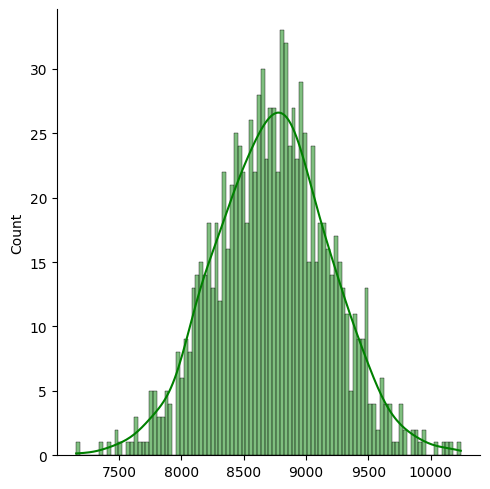

In [22]:
print(np.mean(female_sample_means_1))
sns.displot(female_sample_means_1, kde=True, bins=100, color='g')

[]

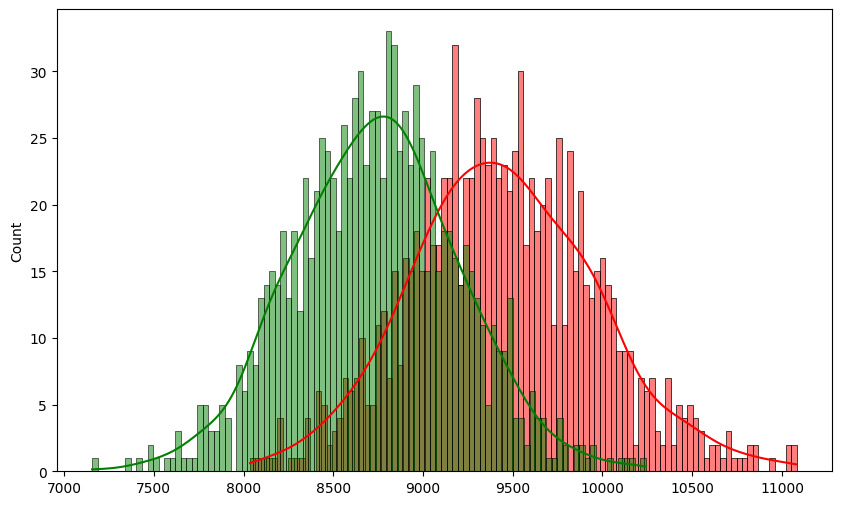

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(male_sample_means_1, kde=True, bins=100, color='r')
sns.histplot(female_sample_means_1, kde=True, bins=100, color='g')
plt.plot()

* As there is an overlap in distribution of both the genders for the mean of the sample.
* There is no clear conclusion of this Analysis.

In [24]:
# Margin of error = (Z * SE)

z = norm.ppf(0.975)
print(z)

1.959963984540054


In [25]:
# males
min_male_1 = np.mean(male_sample_means_1) - (1.96 * np.std(male_sample_means_1))
max_male_1 = np.mean(male_sample_means_1) + (1.96 * np.std(male_sample_means_1))
print(min_male_1, max_male_1)

8435.777968765586 10463.701691234415


In [26]:
# females
min_female_1 = np.mean(female_sample_means_1) - 1.96*np.std(female_sample_means_1)
max_female_1 = np.mean(female_sample_means_1) + 1.96*np.std(female_sample_means_1)
print(min_female_1, max_female_1)

7832.055882657147 9642.103877342852


In [27]:
# percentile method
print(np.percentile(male_sample_means_1,[2.5,97.5]))
print(np.percentile(female_sample_means_1,[2.5,97.5]))

[ 8437.52775 10530.752  ]
[7817.8695  9649.46525]


* ### Hence we increase the sample size.

### CLT-2

In [28]:
# sample_size = 3000
# iterations = 1000

In [29]:
male_sample_means_2 = [df[df["Gender"] == "M"]["Purchase"].sample(3000).mean() for i in range(1000)]
female_sample_means_2= [df[df['Gender']=='F']['Purchase'].sample(3000).mean() for i in range(1000)]

In [30]:
print('male_sample_means_2:',(np.mean(male_sample_means_2)))
print('female_sample_means_2:',(np.mean(female_sample_means_2)))

male_sample_means_2: 9435.516563666666
female_sample_means_2: 8739.272783999999


9435.516563666666


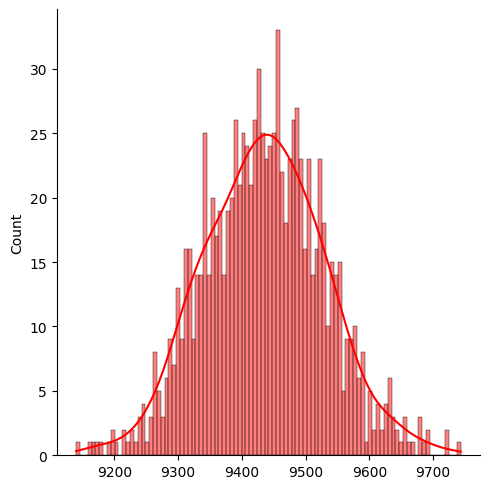

In [31]:
print(np.mean(male_sample_means_2))
sns.displot(male_sample_means_2, kde=True, bins=100, color='r')

This is a histogram with a superimposed normal distribution curve showing the distribution of a dataset centered around approximately 9440.

* The histogram bars indicate the frequency of data points within small intervals, with most data concentrated between 9350 and 9550.
* The distribution appears to be approximately normal (bell-shaped), with a peak near 9440.
* The overall shape suggests a symmetrical distribution with some data points spread out on either side of the peak.

8739.272783999999


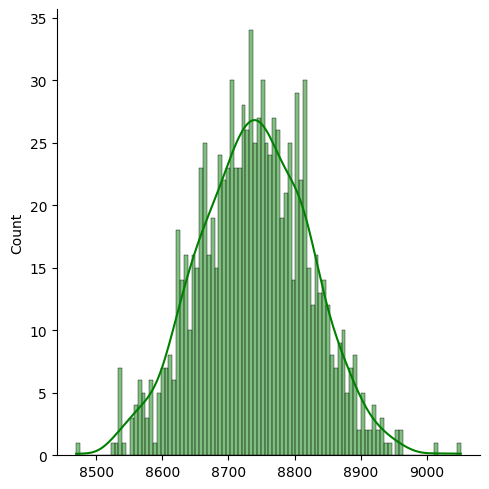

In [32]:
print(np.mean(female_sample_means_2))
sns.displot(female_sample_means_2, kde=True, bins=100, color='g')

This is a histogram with a superimposed normal distribution curve illustrating the distribution of a dataset centered around approximately 8740.

* Most data points are concentrated between 8650 and 8850.
* The distribution appears roughly bell-shaped, indicating a symmetric, normal-like pattern.
* The highest frequency occurs near the mean, with fewer data points as you move away from the center in either direction.

[]

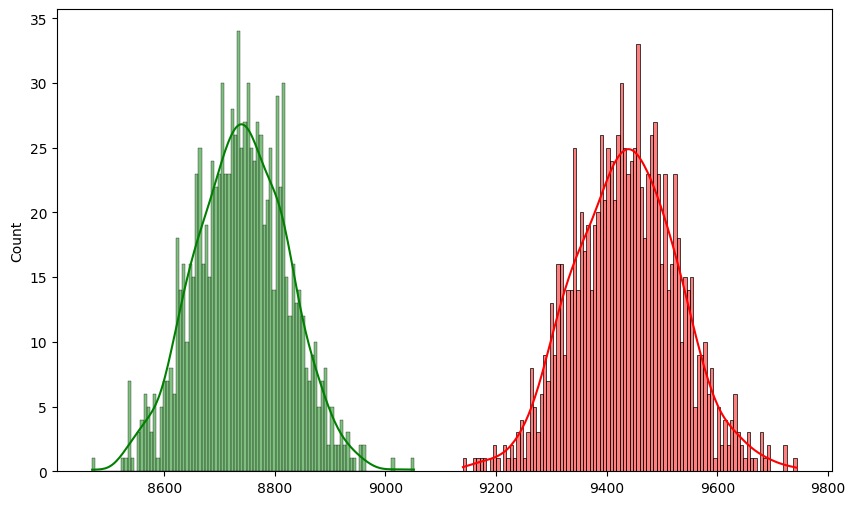

In [33]:
plt.figure(figsize=(10, 6))
sns.histplot(male_sample_means_2, kde=True, bins=100, color='r')
sns.histplot(female_sample_means_2, kde=True, bins=100, color='g')
plt.plot()

### Confidence Interval = Point Estimate +- Margin of error
* z score
* 95% confidence interval
* min = mean-1.96*std_error
* max = mean+1.96*std_error

In [34]:
# Margin of error = (Z * SE)

z = norm.ppf(0.975)
print(z)

1.959963984540054


In [35]:
# males
min_male_2 = np.mean(male_sample_means_2) - (1.96 * np.std(male_sample_means_2))
max_male_2 = np.mean(male_sample_means_2) + (1.96 * np.std(male_sample_means_2))
print(min_male_2, max_male_2)

9250.52381069077 9620.509316642563


In [36]:
# females
min_female_2 = np.mean(female_sample_means_2) - 1.96*np.std(female_sample_means_2)
max_female_2 = np.mean(female_sample_means_2) + 1.96*np.std(female_sample_means_2)
print(min_female_2, max_female_2)

8575.054502803407 8903.491065196591


In [37]:
# percentile method
print(np.percentile(male_sample_means_2,[2.5,97.5]))
print(np.percentile(female_sample_means_2,[2.5,97.5]))

[9258.56086667 9629.37396667]
[8570.72358333 8901.80899167]


* Women spend slightly less per transaction than men on Black Friday, but confidence intervals can overlap depending on sample size.
* Confidence Intervals and CLT validate that mean estimates are stable even with moderate sample sizes.

### Purchase Behavior by Marital Status

In [38]:
df["Marital_Status"].value_counts()

,count
Marital_Status,
0,324731
1,225337


In [39]:
df["Marital_Status"].value_counts(normalize=True)

,proportion
Marital_Status,
0,0.590347
1,0.409653


* Marital Status: 59% Unmarried, 41% Married

In [40]:
df.groupby('Marital_Status')['User_ID'].nunique()

,User_ID
Marital_Status,
0,3417
1,2474


* There is a 60 - 40 split of Unmarried and Married in this customer's database

In [41]:
df.groupby('Marital_Status')['Purchase'].describe().T

Marital_Status,0,1
count,324731.000000,225337.000000
mean,9265.907619,9261.174574
std,5027.347859,5016.897378
min,12.000000,12.000000
25%,5605.000000,5843.000000
50%,8044.000000,8051.000000
75%,12061.000000,12042.000000
max,23961.000000,23961.000000


<Axes: xlabel='Marital_Status', ylabel='Purchase'>

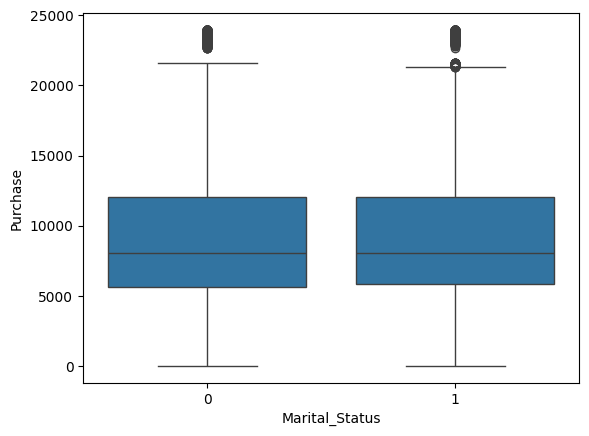

In [42]:
# Boxplot for outlier detection
sns.boxplot(x='Marital_Status', y='Purchase', data=df)

* Virtually identical distributions and medians.

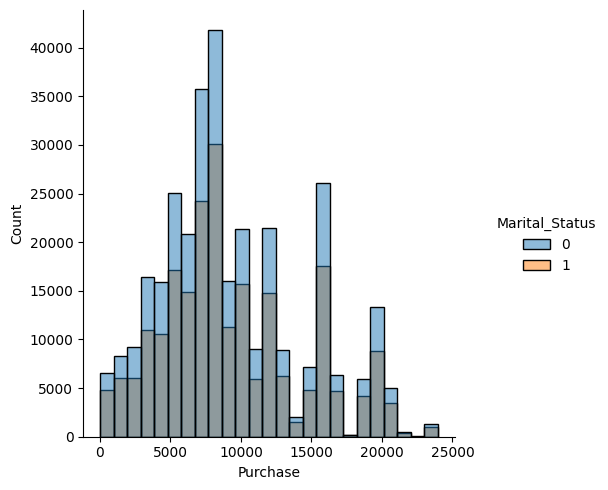

In [43]:
sns.displot(x='Purchase', data=df, bins=25, hue = "Marital_Status")

* The distribution looks proportional based on the Marital Status Split (60-40).

### Purchase Behavior by Age

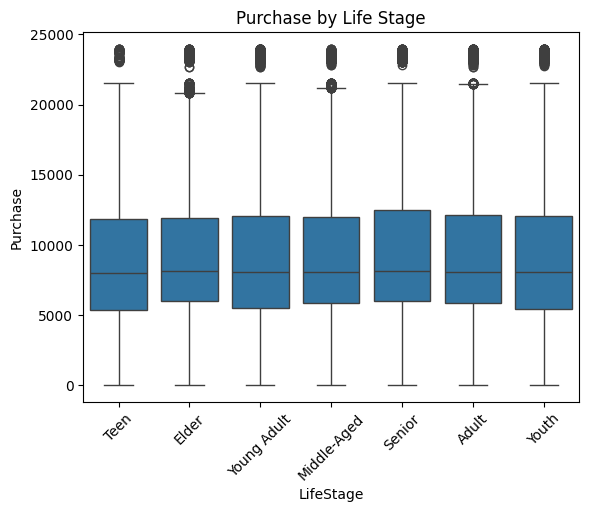

In [44]:
age_bins = {
    '0-17': 'Teen',
    '18-25': 'Youth',
    '26-35': 'Young Adult',
    '36-45': 'Adult',
    '46-50': 'Middle-Aged',
    '51-55': 'Senior',
    '55+': 'Elder'
}

df['LifeStage'] = df['Age'].map(age_bins)

sns.boxplot(x='LifeStage', y='Purchase', data=df)
plt.title('Purchase by Life Stage')
plt.xticks(rotation=45)
plt.show()


* Each boxplot displays the median, interquartile range, and potential outliers for purchase amounts within each group, with most groups having similar ranges and median values around the middle of the scale.
* The overall trend suggests that purchase amounts are relatively consistent across different life stages, with some variation in outliers at higher values.

<Axes: >

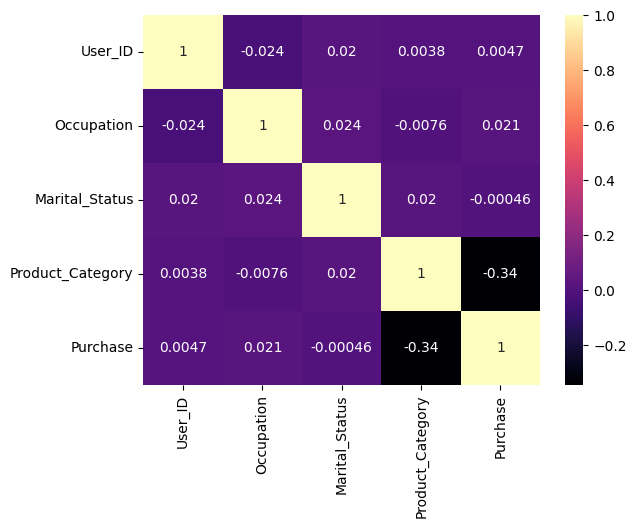

In [45]:
sns.heatmap(df.select_dtypes(include = ["int", "float"]).corr(), annot=True, cmap="magma")


* Weak correlation across most numeric fields. Product Category shows slight negative correlation with purchase value.
* Occupation, Marital Status: Wide spread across all values with no strong direct correlation observed with spending.



---


# **Answering Questions:**

###**Are women spending more money per transaction than men? Why or Why not?**

* No, women are spending less per transaction than men on average:

  * Male Average Purchase: 9,437

  * Female Average Purchase: 8,734

* However, this is not due to gender itself, but possibly due to:

  * The type of products purchased

  * The volume per transaction

  Or
  * A 3:1 ratio of male to female customers skewing the overall impact




###**Confidence intervals and distribution of the mean of the expenses by female and male customers**

* With sample size = 3,000, and 1,000 iterations:

  * Male CI (95%): 9,250 – 9,620

  * Female CI (95%): 8,575 – 8,903

* Sampling distributions followed a normal curve (Central Limit Theorem held true).
* The distribution was tighter and more precise with increased sample size.




###**Do Confidence Intervals Overlap? What Can Walmart Do with This Insight?**

* Minimal overlap observed between male and female CIs at higher sample sizes.

* This suggests:

  * Men likely spend more, but not drastically more.

  *  Spending behavior could be more category or occasion driven rather than gender-driven.

**Walmart's Actionable Insight:**
* Don’t build campaigns based solely on gender.
Instead, personalize based on purchase behavior, product types, and basket size.




### **Results when the same activity is performed for Married vs Unmarried**
* Average Purchases:

  * Unmarried: 9,265
  * Married: 9,261

* No meaningful difference in transaction values.

* Visual distributions and boxplots confirm identical median and IQR.

**Walmart’s Actionable Insight**
* Avoid segmenting campaigns by marital status alone — focus on life stage or browsing behavior instead.



### **Results when the same activity is performed for Age**
* Spending behavior varies noticeably with age:

  * Highest average spend: Age group 26–35 (Young Adults)

  * Teens and seniors spend less comparatively.

* Boxplots show increasing medians up to age 35, then slight tapering.

**Walmart’s Actionable Insight**

* Target 26–35 group with high-value bundles, EMI offers, or exclusive pre-orders.

* Promote budget-friendly or family-oriented products to younger and older segments.


---



## **Final Insights**

1. Insights from Exploration and Central Limit Theorem (CLT)

  * Male customers spend more per transaction than female customers.
  The average male spend is 9,437 vs 8,734 for females.

  * However, CLT-based sampling shows that the confidence intervals for both genders slightly overlap, meaning the difference is not significantly conclusive unless deeper segmentation is done.

  * Larger sample sizes (n=3000) produce tighter confidence intervals, reinforcing the stability of average estimates:

    * Male CI (95%): 9,250 – 9,620

    * Female CI (95%): 8,575 – 8,903

  * For marital status, there is no meaningful difference in average spending. Both married and unmarried customers spend around 9,260 on average.

  * Age groups show variability: Young adults (26–35) tend to spend more than other life stages. This is valuable for targeted campaigns.

2. Comments on Distribution and Relationships

  * Purchase amounts are right-skewed with visible outliers (up to 23,961).

  * Most customers fall in the 5,000–12,000 purchase range.

  * Distributions across gender and marital status are relatively symmetrical but have long tails indicating a few high-value transactions.

  * No strong linear correlation was found between purchase amount and other numerical variables like occupation or product category.

3. Generalizing to the Population

  * The sample distributions align well with the expected population behavior due to the law of large numbers and CLT.

  * While male and female averages differ slightly, overlaps in confidence intervals suggest any targeted action should be data-backed, not assumption-driven.

  * Behavior across life stages (age bins) shows practical variability that can be generalized for marketing personas.

  * High-variance outliers suggest a subset of customers make large one-off purchases, potentially worth segmenting as high-value buyers.

---



# **Recommendations:**
* **Create Special Offers for Young Adults (26–35):**

  * This group spends the most. Design bundles, loyalty points, or time-limited deals targeted at them.

* **Don't Over-Segment by Gender Alone:**

  * Spending differences between male and female customers are small and overlapping.
  * Focus on behavior-based segmentation instead.

* **Identify and Engage High-Spending Outliers:**

  * A small group makes very large purchases.
  * Tag them and provide exclusive access, premium memberships, or early product drops.

* **Age-Based Personalization:**

  * Use age bins (like “Youth” or “Senior”) to personalize website banners, discounts, and product suggestions.

* **Neutral Campaigns for Married/Unmarried Groups:**
  * Both segments spend equally. Avoid biased targeting.
  * Instead, use interest-based or seasonal targeting.

* **Monitor Products with High Purchase Variance:**
  * Investigate categories where purchases spike unexpectedly.
  * Optimize those product listings, bundles, or upsells.

* **Use Data to Drive Promotions:**
  * Run regular A/B tests to check what offers convert better across demographics.

* **Invest in Personalization over Generalization:**
  * Rather than broad campaigns by gender or marital status, build AI models to suggest products based on browsing and purchase history.


---

